In [7]:
# Scatter plot
# when both x and y are numerical data

## line chart 
# it is between categorical vs numerical 

## bar chart
# categorical vs numerical 

# stacked bar plot
# more then one categorical part vs numerical 

# pie chart
# it is categorical in percentage or ratio 
 
## box plot 
# it is uses stat 
# it has outliers 

In [8]:
# importing the libraries we need in the visualization part 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

In [9]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [10]:
df_1 = pd.read_excel('./online_retail_II.xlsx',sheet_name= 'Year 2009-2010')
df_2 = pd.read_excel('./online_retail_II.xlsx',sheet_name= 'Year 2010-2011')

In [9]:
df = pd.concat([df_1, df_2], ignore_index=True)

In [11]:
print(df.shape)

print(df.columns)

(1067371, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [13]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


# Cleaning & Feature Engineering

In [14]:
df = df.dropna(subset=['InvoiceDate', 'Customer ID'])

In [16]:
print(df.shape)

(824364, 8)


In [17]:
df.head(4)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom


In [18]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [19]:
print(df.shape)

(805620, 8)


In [20]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [21]:
print(df.shape)

(805549, 8)


In [22]:
805620 - 805549


71

In [23]:
# Add new features 

df['Revenue'] = df['Quantity'] * df['Price'] # (feature engineering)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str) # (feature engineering)
# 2009-01
# 2009-03

In [24]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


# What is matplotlib

In [ ]:
# matplotlib --> seaborn, pandas plot

# it is handle 2d plots 
# fine tuning as well 
#

In [26]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [27]:
import matplotlib.pyplot as plt

In [29]:
monthly_revenue = df.groupby('Month')['Revenue'].sum().sort_index()

In [30]:
monthly_revenue

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Name: Revenue, dtype: float64

In [31]:
monthly_revenue.head()

Month
2009-12    686654.160
2010-01    557319.062
2010-02    506371.066
2010-03    699608.991
2010-04    594609.192
Name: Revenue, dtype: float64

In [35]:
monthly_revenue.index

Index(['2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05',
       '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11',
       '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05',
       '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11',
       '2011-12'],
      dtype='object', name='Month')

In [44]:
monthly_revenue.values

array([ 686654.16 ,  557319.062,  506371.066,  699608.991,  594609.192,
        599985.79 ,  639066.58 ,  591636.74 ,  604242.65 ,  831615.001,
       1036680.   , 1172336.042,  884591.89 ,  569445.04 ,  447137.35 ,
        595500.76 ,  469200.361,  678594.56 ,  661213.69 ,  600091.011,
        645343.9  ,  952838.382, 1039318.79 , 1161817.38 ,  518210.79 ])

# line - plot

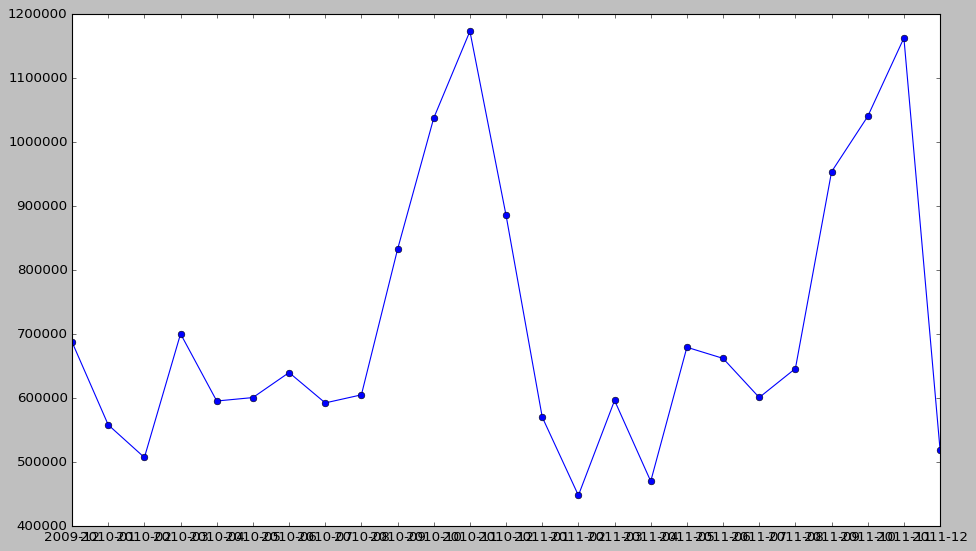

In [45]:
plt.figure(figsize=(14, 8))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.show()

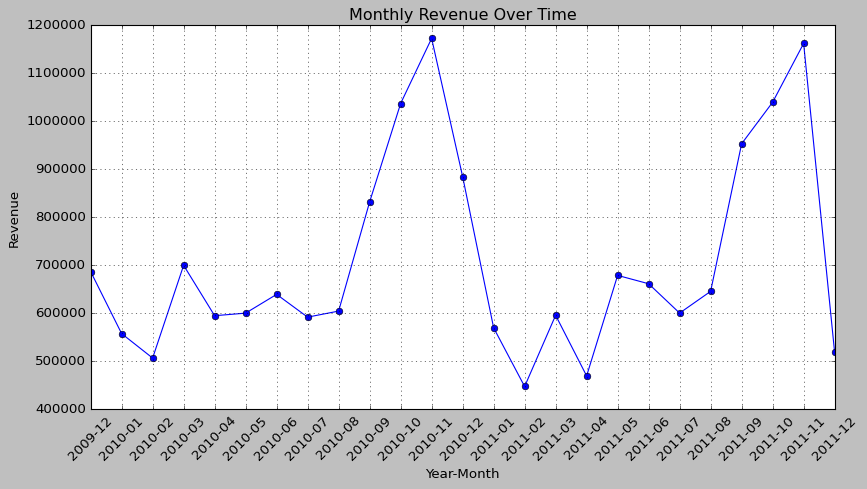

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)  # lables of x rotated by 45 degree
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True)  # for the grid lines 
plt.show()

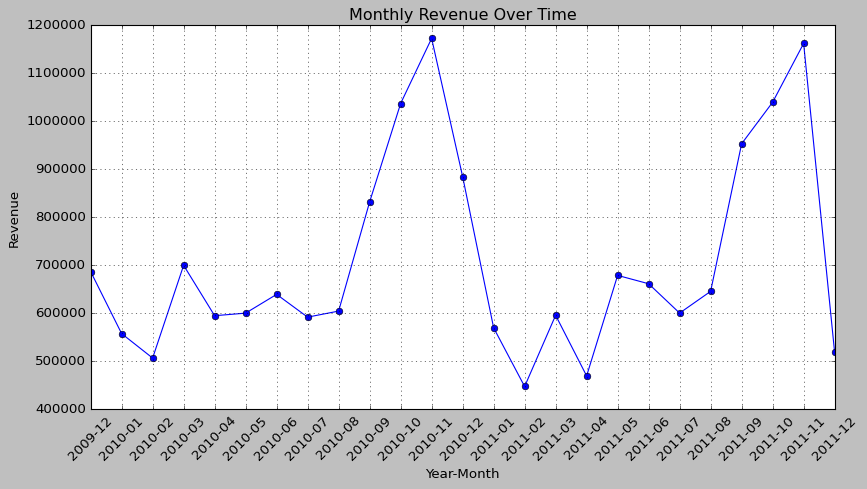

In [42]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('classic')  # giving style to the marker  
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

In [47]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


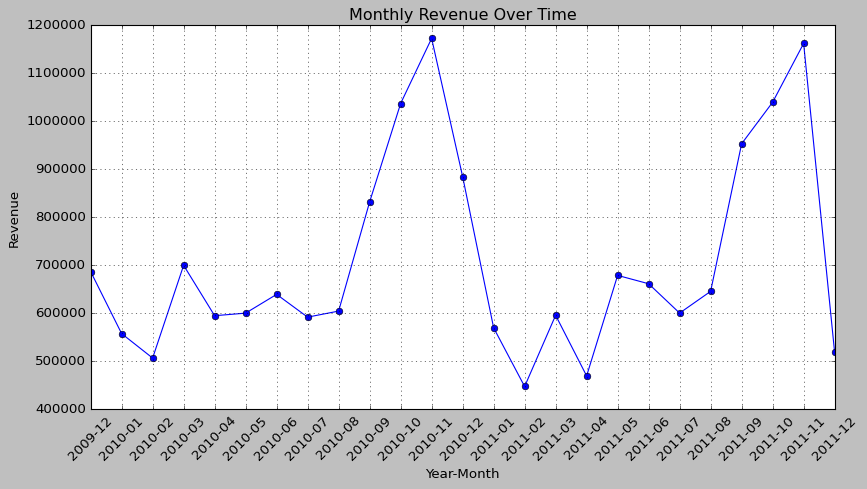

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('classic')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.savefig("monthly_revenue_plot.png", dpi=300)   # it for saving the plot png 

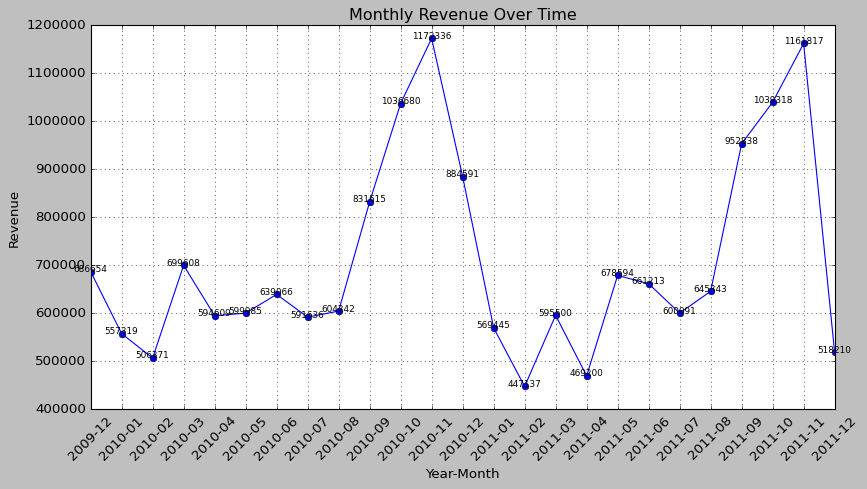

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('ggplot')
plt.title('Monthly Revenue Over Time')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value, f"{int(value)}", ha='center', fontsize=8)


plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

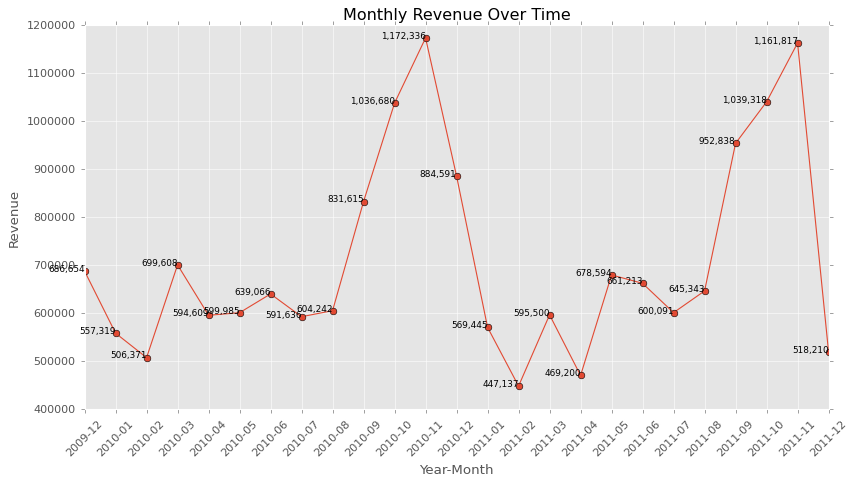

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('ggplot')
plt.title('Monthly Revenue Over Time')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value, f"{int(value):,}", ha='right', color='black',fontsize=8)


plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

# 1000 > 1,000
# 10000 > 10, 0000

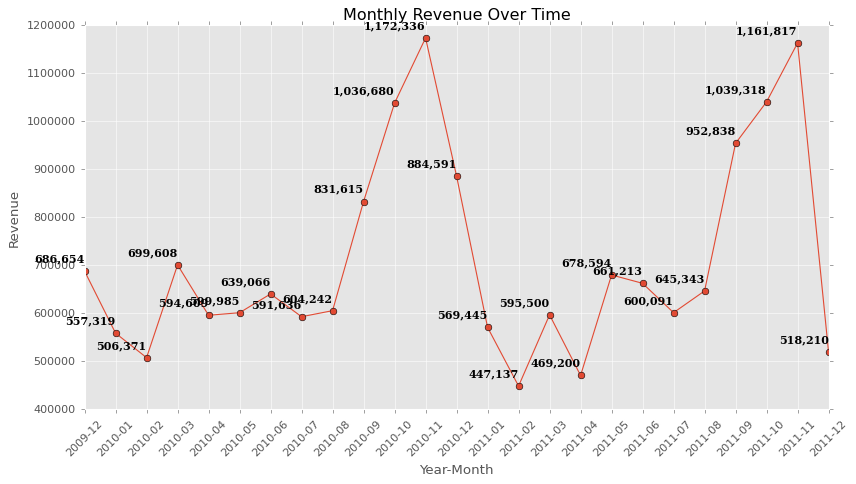

In [52]:
font = {
    'family': 'serif',
    'color':  'black',
    'weight': 'bold',
    'size': 10,
}

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('ggplot')
plt.title('Monthly Revenue Over Time')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value+20000, f"{int(value):,}", fontdict=font, ha='right')


plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

In [53]:
# Show top 10 revenue-generating countries

In [54]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [55]:
country_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

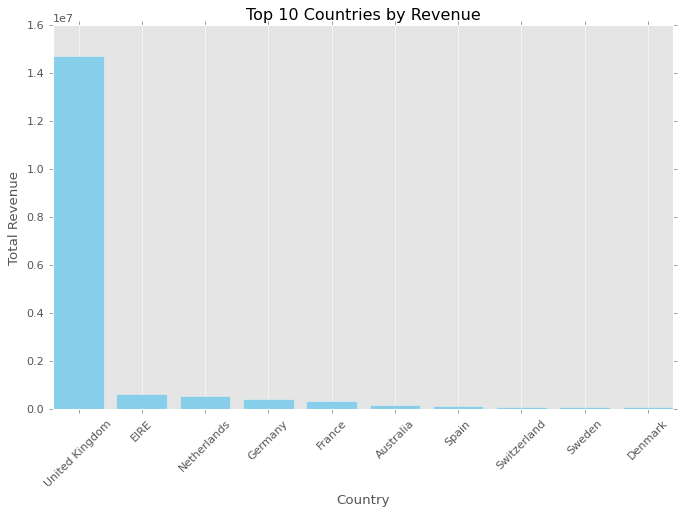

In [ ]:
# Bar plot

plt.figure(figsize=(10, 6))
plt.bar(country_revenue.index, country_revenue.values, color='skyblue') # vertical bar plot 

# Customizations
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

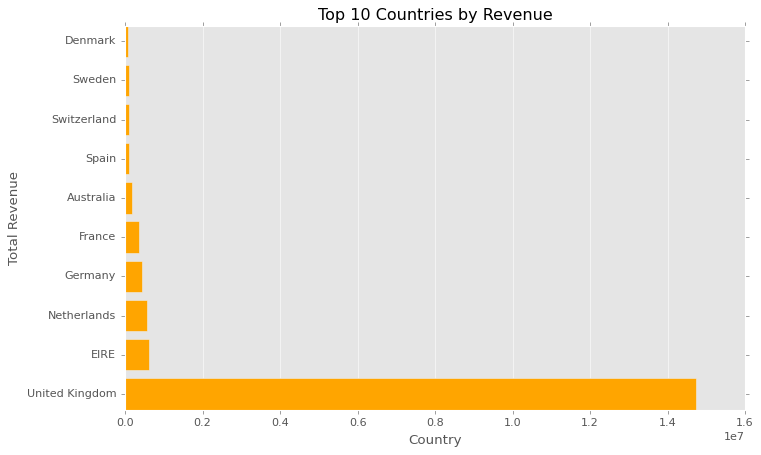

In [60]:
# Bar plot

plt.figure(figsize=(10, 6))
plt.barh(country_revenue.index, country_revenue.values, color='orange')

# Customizations
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
# plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

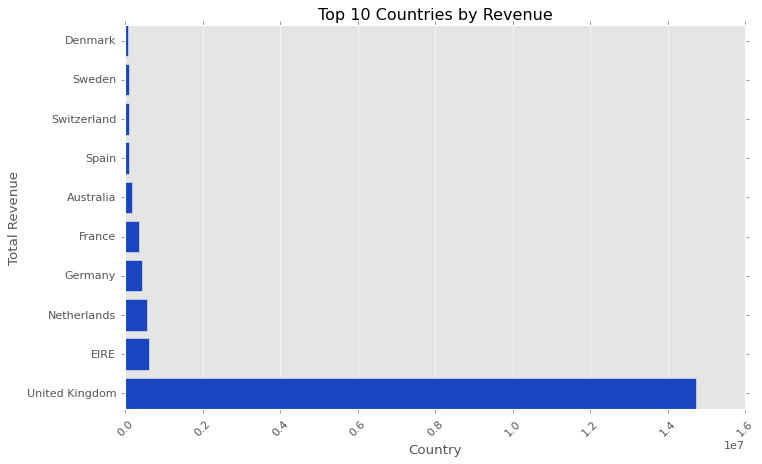

In [ ]:
# Bar plot

plt.figure(figsize=(10, 6))
plt.barh(country_revenue.index, country_revenue.values, color='#1945C1')  # copy hte hex code of html color code 
# #1945c1 

# Customizations
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [1]:
import random

In [2]:
random.seed(123)

In [3]:
random_number = random.randint(1, 100) 
print(random_number)

7


In [5]:
random_number = random.randint(1, 100) 
print(random_number)

12


In [ ]:
# scatter plot

sample_df = df.sample(100, random_state=random_number)

NameError: name 'df' is not defined

In [ ]:
sample_df.head(10)

In [ ]:
sample_df.info()

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df['Quantity'], sample_df['Revenue'], alpha=0.5, color='purple')
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Sub-Plots : Multiple charts in one figure

In [ ]:
# P.S : Compare PLOT(1)monthly revenue by PLOT(2) monthly quantity

In [ ]:
monthly_quantity = df.groupby('Month')['Quantity'].sum().sort_index()

In [ ]:
monthly_quantity.head()

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

axs[0].plot(monthly_quantity.index, monthly_quantity.values, marker='o', color='blue', label='Quantity')
axs[0].set_title("Monthly Quantity")
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Quantity")
axs[0].grid(True)

axs[1].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue')
axs[1].set_title("Monthly Revenue")
axs[1].set_xlabel("Month")
axs[1].set_ylabel("Revenue")
axs[1].grid(True)

plt.xticks(rotation=45)
plt.show()

# Seaborn

In [ ]:
%pip install seaborn

In [ ]:
import seaborn as sns

In [ ]:
# Distribution of Quantity per Transaction

In [ ]:
df_quantity = df[(df['Quantity'] > 0) & (df['Quantity'] < 100)]

In [ ]:
# 1,2,3,....99 --> hist --> freq
# 99 column
# 1-10 --> bar
# 11-20 --> bar

# bins = 10

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity['Quantity'], bins=10, kde=False, color='skyblue')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity['Quantity'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.kdeplot(df_quantity['Quantity'], fill=True, color='green')
plt.title('Quantity KDE Curve')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

# Categorical data Visualization

In [ ]:
df.info()

In [ ]:
# Top Countries by Revenue (Bar Plot) (top-10)

In [ ]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [ ]:
top_countries.head()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
# Number of Transactions by Country (Count Plot)
df_sample = df[['Quantity', 'Price', 'Revenue', 'Country', 'Month']].copy()

In [ ]:
df_sample.head()